# Bayesian Modeling to characterize the reliability of SC

In [32]:
import h5py
import os
import pickle
import arviz as az
import numpy as np
import pymc as pm
import seaborn as sns
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from simulate_sc import (
    simulate_sc_no_bias,
    simulate_sc_noisy_copies,
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)

from bayesian_modeling import fit_mixture_model

atlas_path = "/data/probconnatlas/wm.connatlas.scale1.h5"
# Load consistency matrix
with h5py.File(atlas_path, "r") as f:
        print(f.keys())
        print(f["matrices"].keys())
        consistency_matrix = np.array(f["matrices"]["consistency"])
        print("Loaded consistency matrix")
        print(consistency_matrix)
        density_matrix = np.array(f["matrices"]["numbStlines"])

<KeysViewHDF5 ['atlas', 'header', 'matrices']>
<KeysViewHDF5 ['consistency', 'length', 'numbStlines']>
Loaded consistency matrix
[[66 65 65 ...  0  1 66]
 [65 65 65 ...  0  0 60]
 [65 65 60 ...  0  0 15]
 ...
 [ 0  0  0 ... 17 64 57]
 [ 1  0  0 ... 64 66 66]
 [66 60 15 ... 57 66 66]]


We can determine if a connection exists or not based on the consistency matrix from Yasser's atlas. To binarize the consistency matrix, we have to choose a threshold.

Threshold to binarize consistency matrix: 47.0


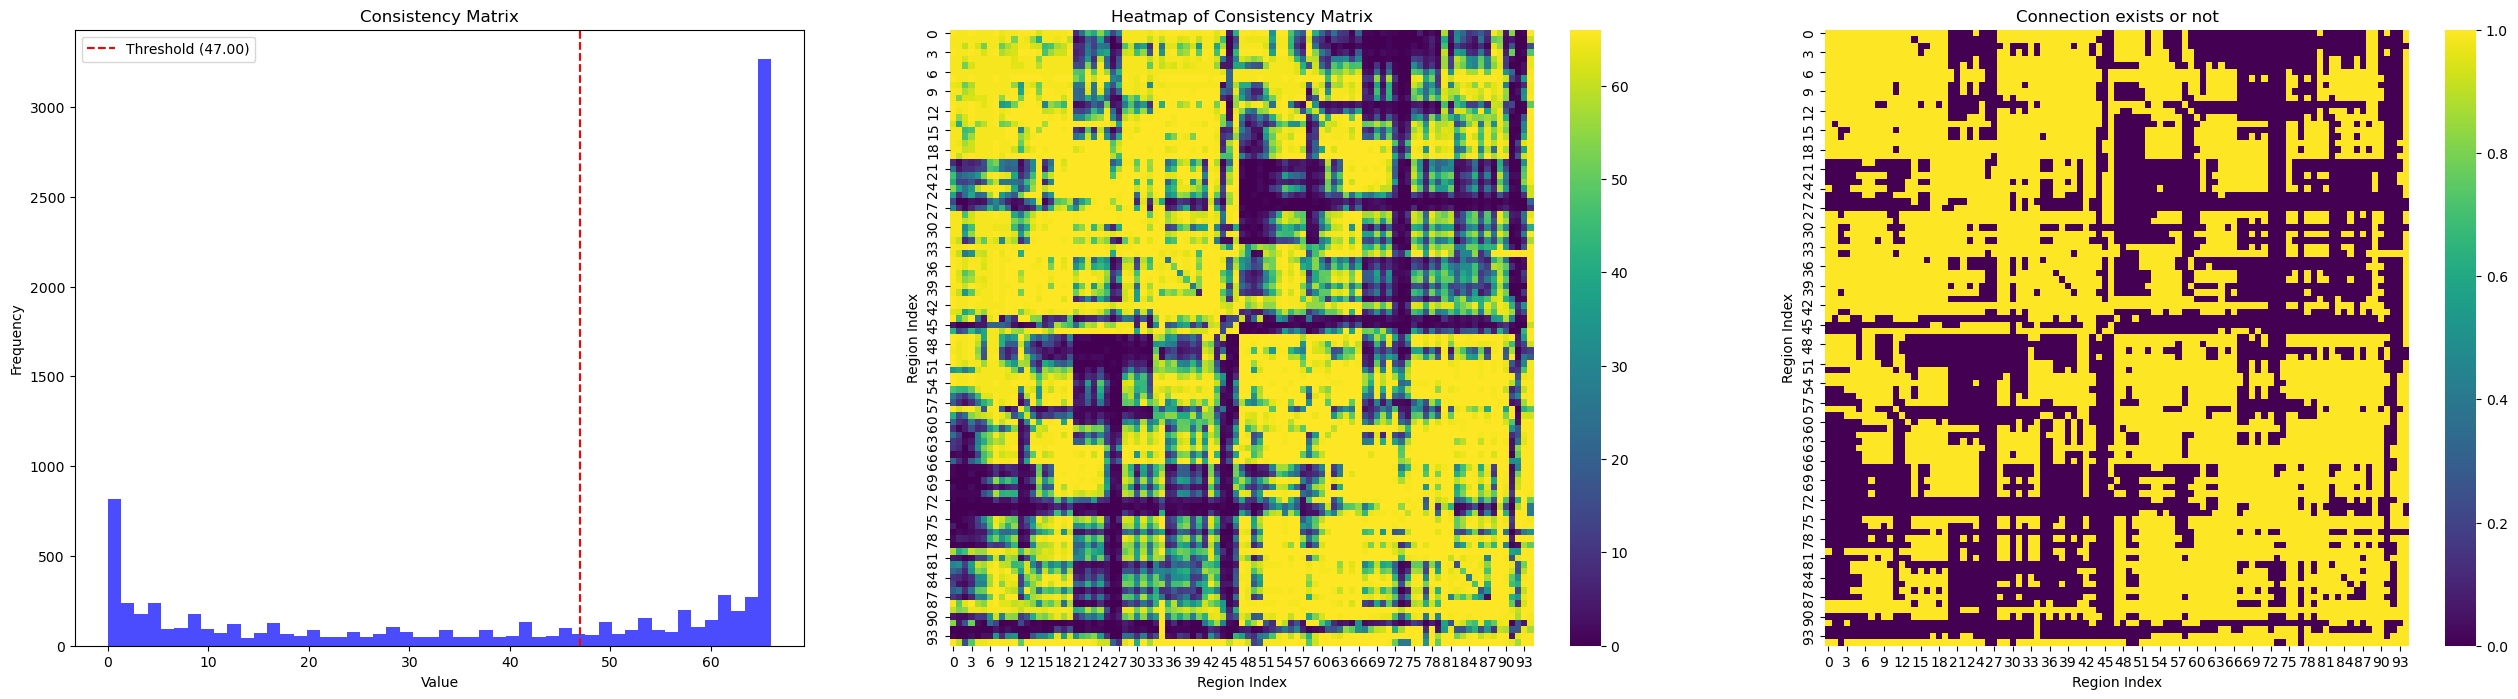

In [33]:
threshold = np.percentile(consistency_matrix[consistency_matrix>0], 40)
print("Threshold to binarize consistency matrix:", threshold)

# Plot histogram for consistency_matrix
plt.figure(figsize=(32, 8))
plt.subplot(1, 3, 1)
plt.hist(consistency_matrix.flatten(), bins=50, color='blue', alpha=0.7)
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.legend()
plt.title('Consistency Matrix')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.heatmap(consistency_matrix, cmap='viridis', cbar=True)
plt.title('Heatmap of Consistency Matrix')
plt.xlabel('Region Index')
plt.ylabel('Region Index')

plt.subplot(1, 3, 3)
sns.heatmap(consistency_matrix > threshold, cmap='viridis', cbar=True)
plt.title('Connection exists or not')
plt.xlabel('Region Index')
plt.ylabel('Region Index')
plt.show()

Using the connectome atlas as reference SC matrix.
Simulated a series of 36 SC matrices of shape (95x95) with higher variability (std=0.5) in lower density connections.


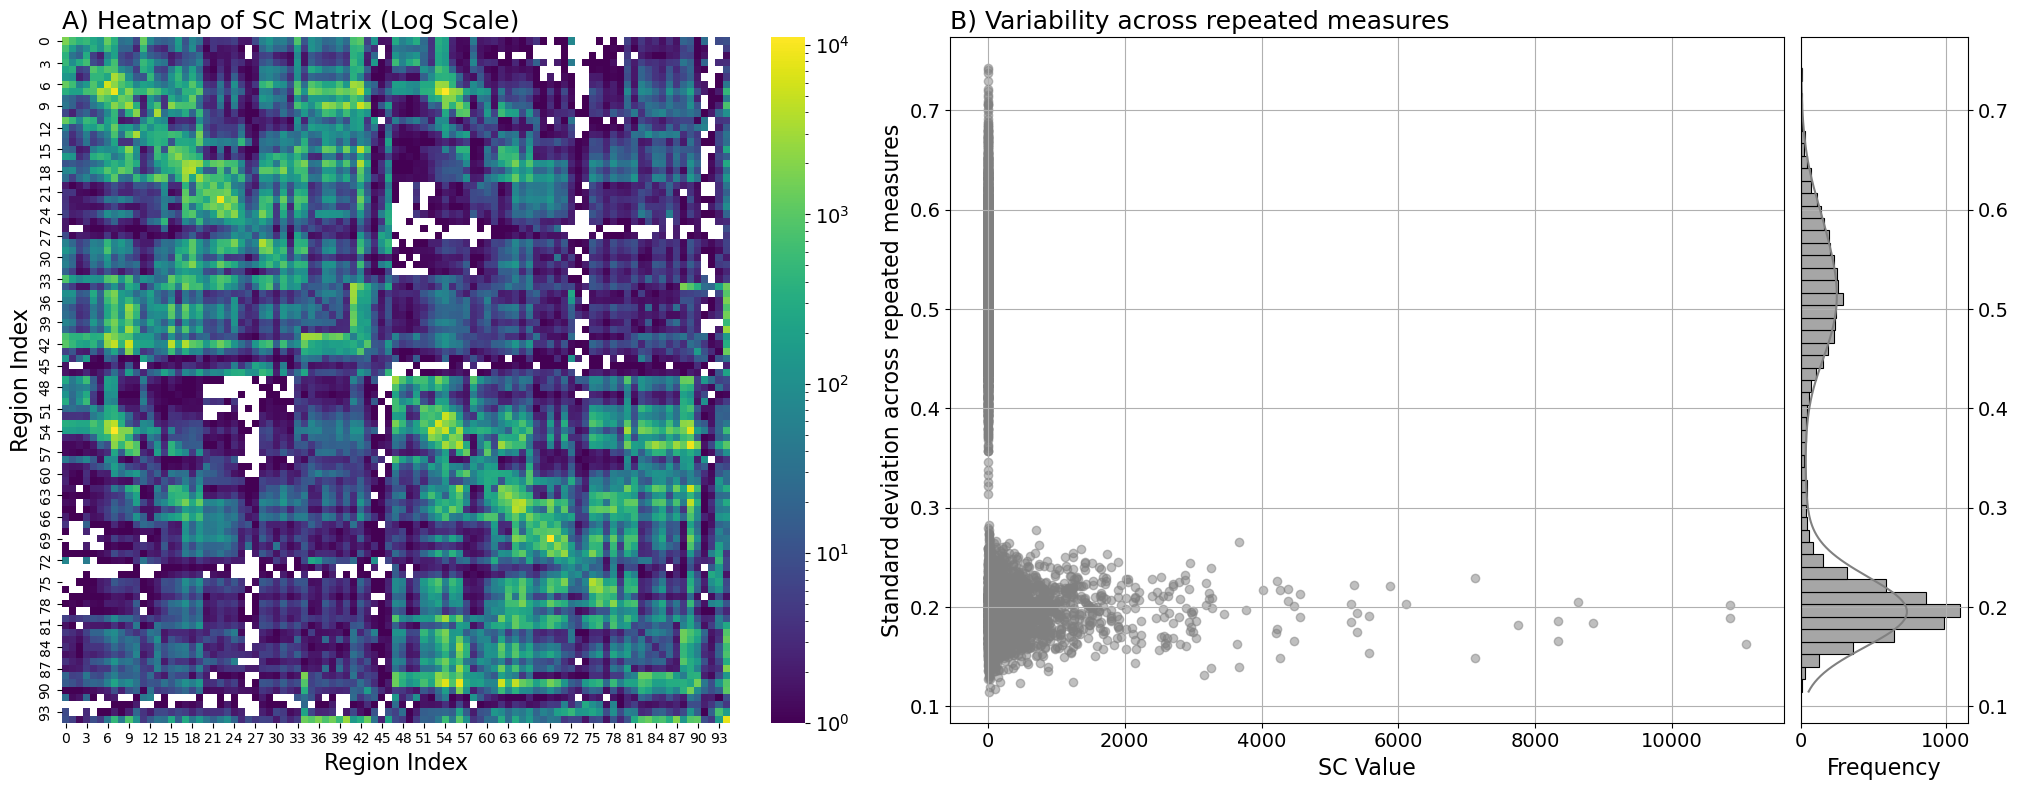

In [34]:
from matplotlib.colors import LogNorm

# Load simulated SC
SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path, connectome_atlas_as_ref=True, num_sessions=36, atlas_dim=5)
#SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path)
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]

ref_SC_matrix = density_matrix

variability = np.std(SC_matrices, axis=0)

fig, (ax_heatmap, ax_scatter) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1]})

# Heatmap of the density matrix
sns.heatmap(ref_SC_matrix, cmap='viridis', cbar=True, norm=LogNorm(vmin=np.nanmin(ref_SC_matrix[ref_SC_matrix > 0]), vmax=np.nanmax(ref_SC_matrix)), ax=ax_heatmap)
ax_heatmap.set_title('A) Heatmap of SC Matrix (Log Scale)', fontsize=18, loc='left')
ax_heatmap.set_xlabel('Region Index', fontsize=16)
ax_heatmap.set_ylabel('Region Index', fontsize=16)
cbar = ax_heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

# Scatter plot
scatter = ax_scatter.scatter(ref_SC_matrix.flatten(), variability.flatten(), alpha=0.5, color='grey')
ax_scatter.set_title('B) Variability across repeated measures', fontsize=18, loc='left')
ax_scatter.set_xlabel('SC Value', fontsize=16)
ax_scatter.set_ylabel('Standard deviation across repeated measures', fontsize=16)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.grid(True)

# Add distribution of variability as a marginal histogram on the right
ax_hist = ax_scatter.inset_axes([1.02, 0, 0.2, 1])  # [x, y, width, height] relative to ax_scatter
sns.histplot(y=variability.flatten(), bins=50, color='grey', alpha=0.7, kde=True, ax=ax_hist)
ax_hist.set_xlabel('Frequency', fontsize=16)
ax_hist.tick_params(axis='both', which='major', labelsize=14, right=True, labelright=True, left=False, labelleft=False)
ax_hist.grid(True)

plt.tight_layout()
plt.show()

In [35]:
# Compute the percentage of zero connections
zero_connections_percentage = np.sum(consistency_matrix < threshold) / consistency_matrix.size * 100
print(f"Percentage of zero connections: {zero_connections_percentage:.2f}%")

Percentage of zero connections: 42.58%


## Bayesian model fitted to our simulated SC matrices

Because the code needed to let the code run in the background overnight, we move the fitting of the Bayesian model in its own standalone Python code `run_bayesian_sc.py`.

!! Please run that code to generate the output files saving the trace and parameters evaluation from Bayesian modeling before running the rest of this notebook. !!

In [ ]:
def load_edge(output_dir, c, SC_matrices_flat, mu_type="fixed"):
    pkl_file = os.path.join(output_dir, f"edge_{c:05d}.pkl")
    trace_file = os.path.join(output_dir, f"edge_{c:05d}_trace.nc")

    if os.path.exists(pkl_file):
        with open(pkl_file, "rb") as f:
            param_values = pickle.load(f)
    else:
        raise FileNotFoundError(f"File {pkl_file} not found. Please run the model fitting first using run_bayesian_sc.py.")

    if os.path.exists(trace_file):
        trace = az.from_netcdf(trace_file)
    else:
        raise FileNotFoundError(f"File {trace_file} not found. Please run the model fitting first using run_bayesian_sc.py.")

    var_names = ["pi0", "lambda_exp", "sigma"]
    param_values = {}
    if mu_type == "fixed":
        param_values["mu"] = np.mean(SC_matrices_flat[:,c])
    else:
        var_names.append("mu")

    summary = az.summary(trace, var_names=var_names)
    for var in var_names:
        param_values[f"{var}_sd"] = summary.loc[var, "sd"]
        
    return param_values

NameError: name 'fixed' is not defined

In [ ]:
mu_type = "fixed"
output_dir = "/home/cprovins/projects/bayesian_sc/mixture_model_1"
os.makedirs(output_dir, exist_ok=True)
print(f"Shape of SC matrices: {SC_matrices.shape}")
SC_matrices_flat = SC_matrices.reshape(num_sessions, -1)
SC_matrices_flat = np.nan_to_num(SC_matrices_flat, nan=0)

param_values = Parallel(n_jobs=8)(
    delayed(load_edge)(output_dir, c) for c in range(SC_matrices_flat.shape[1])
)

# Collect estimated parameter value into `params` dict
params = {"pi0": [], "lambda_exp": [], "mu": [], "sigma": []}
for res in param_values:
    for k in params:
        params[k].append(res.get(k, np.nan))

Shape of SC matrices: (36, 95, 95)


pi0


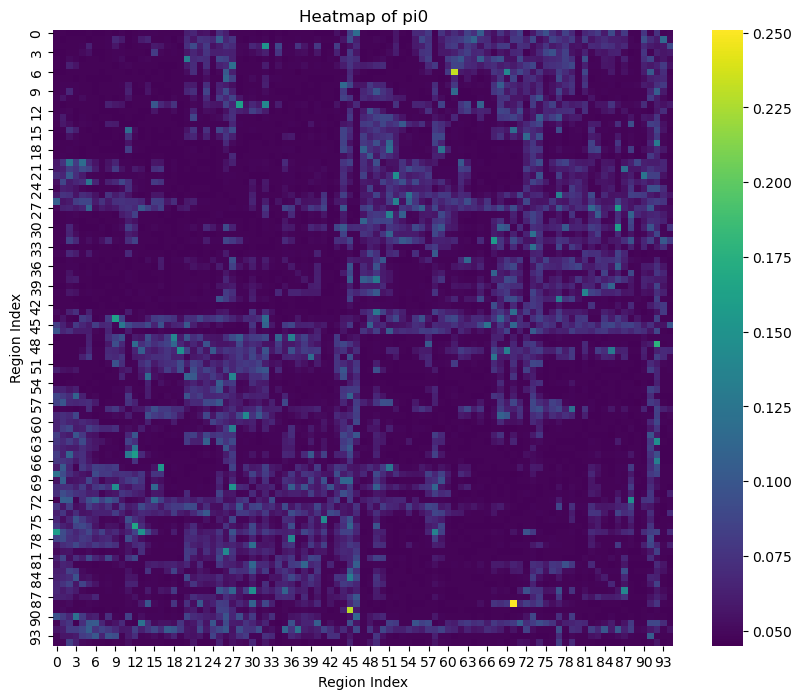

lambda_exp


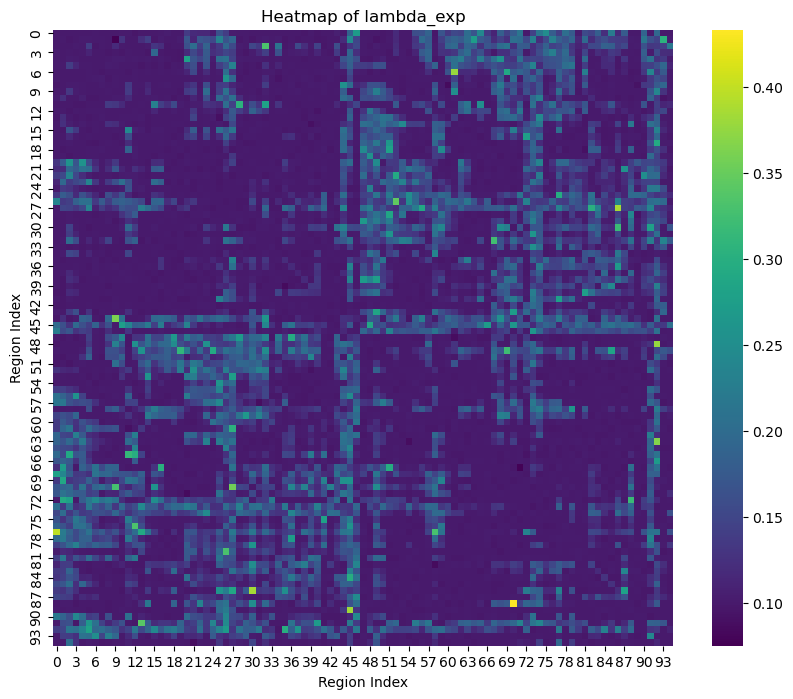

mu


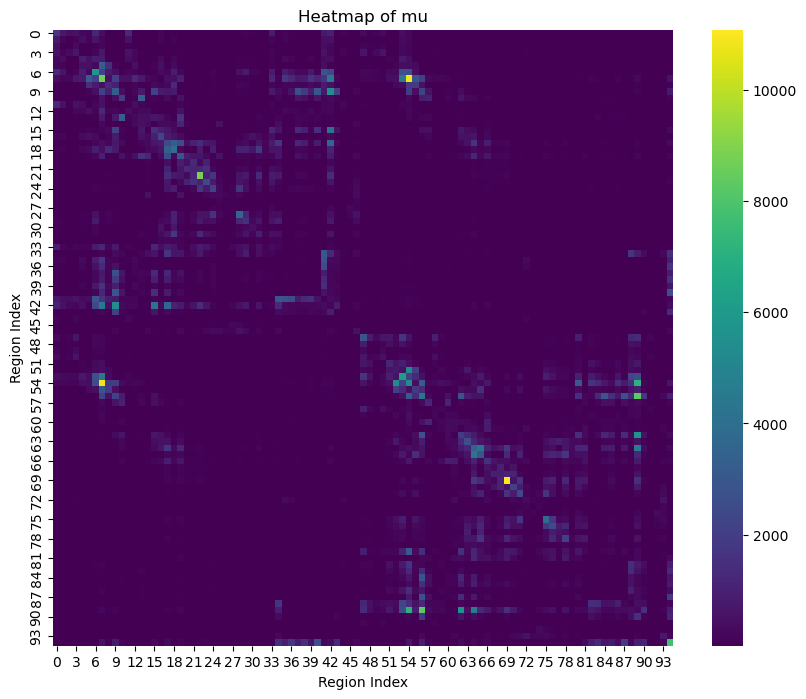

sigma


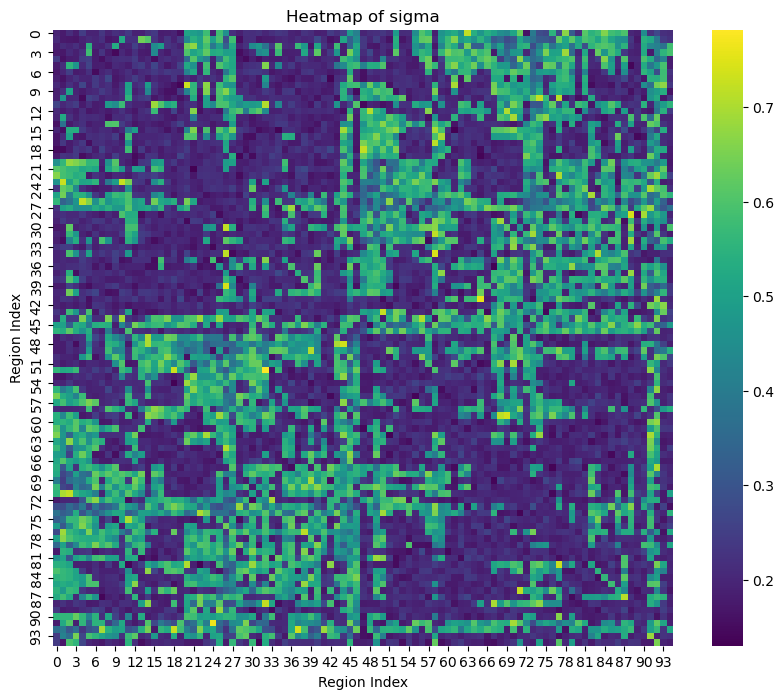

In [ ]:
for p in params:
    print(p)
    param = np.array(params[p]).reshape((atlas_dim, atlas_dim))
    plt.figure(figsize=(10, 8))
    sns.heatmap(param, cmap='viridis', cbar=True)
    plt.title(f'Heatmap of {p}')
    plt.xlabel('Region Index')
    plt.ylabel('Region Index')
    plt.show() 

#### Model QA
##### Trace plot
Plot on the left: A good model converged to the same posterior across runs
Plot on the right: A good model show a homogeneous trace. If you see that in the beginning the trace did not converge to a stable value, you need to not use the samples in the beginning for inference
##### Energy plot
If NUTS algorithm was able to adequately explore the posterior distribution, both displayed distributions should overlap
##### Autocorrelation plot
The trace should not show autocorrelation (i.e. peaks should be scattered around zero, alertnating between negative and positive value and small). A decaying distribution of tall peaks indicates autocorrelation in the trace. Many downstream algorithms require samples to be *independent*, hence the importance of checking that no autocorrelation is present in the trace. If it is, you can use thinning to reduce autocorrelation.